In [34]:
import ast
from configs import BGG_RANKS_FILE, DATA_DIR, FINAL_DATA_FILE
from sklearn.tree import DecisionTreeRegressor
from bgg_api import fetch_games_from_list
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Import boardgames_ranks
rank_df = pd.read_csv(f"{DATA_DIR}/{BGG_RANKS_FILE}")
print(rank_df.columns.tolist())

['id', 'name', 'yearpublished', 'rank', 'bayesaverage', 'average', 'usersrated', 'is_expansion', 'abstracts_rank', 'cgs_rank', 'childrensgames_rank', 'familygames_rank', 'partygames_rank', 'strategygames_rank', 'thematic_rank', 'wargames_rank']


In [3]:
# Filter top 500 games
rank_df = rank_df[rank_df["is_expansion"] == 0].copy()
top500_df = rank_df[rank_df["rank"].between(1, 500)].copy()

print("Top 500 shape:", top500_df.shape)
top500_df.head()

Top 500 shape: (500, 16)


,id,name,yearpublished,rank,bayesaverage,average,usersrated,is_expansion,abstracts_rank,cgs_rank,childrensgames_rank,familygames_rank,partygames_rank,strategygames_rank,thematic_rank,wargames_rank
0,224517,Brass: Birmingham,2018,1,8.39390,8.56536,57997,0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,342942,Ark Nova,2021,2,8.35499,8.54101,60423,0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,161936,Pandemic Legacy: Season 1,2015,3,8.34777,8.50412,57266,0,NaN,NaN,NaN,NaN,NaN,3.0,1.0,NaN
3,174430,Gloomhaven,2017,4,8.29966,8.54115,67001,0,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN
4,397598,Dune: Imperium – Uprising,2023,5,8.23216,8.70180,17936,0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN


In [4]:
# Get top 500 IDs
top500_ids = top500_df["id"].astype(int).tolist()

print("Number of top 500 IDs:", len(top500_ids))
print("First 20 IDs:", top500_ids[:20])

Number of top 500 IDs: 500
First 20 IDs: [224517, 342942, 161936, 174430, 397598, 316554, 233078, 115746, 167791, 187645, 162886, 291457, 220308, 12333, 84876, 418059, 338960, 182028, 193738, 421006]


In [5]:
# Test
sample_ids = top500_ids[:40]
api_sample_df = fetch_games_from_list(sample_ids)

print(api_sample_df.columns.tolist())
print(api_sample_df.shape)
print(api_sample_df.dtypes)

Fetched batch: [224517, 342942, 161936, 174430, 397598, 316554, 233078, 115746, 167791, 187645, 162886, 291457, 220308, 12333, 84876, 418059, 338960, 182028, 193738, 421006]
Fetched batch: [295770, 246900, 28720, 173346, 167355, 169786, 177736, 266507, 124361, 312484, 341169, 205637, 373106, 237182, 120677, 164928, 192135, 266192, 96848, 251247]
['id', 'name', 'yearpublished', 'minplayers', 'maxplayers', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'categories', 'mechanics', 'designers', 'publishers', 'average', 'usersrated', 'bayesaverage', 'stddev', 'owned', 'trading', 'wanting', 'wishing', 'numcomments', 'numweights', 'averageweight']
(40, 24)
id                int64
name             object
yearpublished    object
minplayers       object
maxplayers       object
playingtime      object
minplaytime      object
maxplaytime      object
minage           object
categories       object
mechanics        object
designers        object
publishers       object
average          object

In [6]:
final_df = fetch_games_from_list(top500_ids)

Fetched batch: [224517, 342942, 161936, 174430, 397598, 316554, 233078, 115746, 167791, 187645, 162886, 291457, 220308, 12333, 84876, 418059, 338960, 182028, 193738, 421006]
Fetched batch: [295770, 246900, 28720, 173346, 167355, 169786, 177736, 266507, 124361, 312484, 341169, 205637, 373106, 237182, 120677, 164928, 192135, 266192, 96848, 251247]
Fetched batch: [321608, 199792, 324856, 183394, 284378, 521, 366013, 285774, 175914, 247763, 390092, 365717, 256960, 253344, 3076, 383179, 414317, 184267, 314040, 295947]
Fetched batch: [185343, 102794, 251661, 31260, 170216, 231733, 182874, 240980, 161533, 221107, 255984, 371942, 126163, 2651, 205059, 216132, 380607, 244521, 266810, 35677]
Fetched batch: [125153, 124742, 367966, 164153, 200680, 337627, 276025, 366161, 322289, 209010, 332772, 284083, 28143, 55690, 157354, 230802, 277659, 201808, 159675, 93]
Fetched batch: [413246, 72125, 359871, 256916, 291453, 110327, 436217, 191189, 229853, 359609, 317985, 364073, 62219, 279537, 12, 68448, 22

In [7]:
# Make a copy
clean_df = final_df.copy()

# Convert numeric columns
numeric_columns = [
    "id",
    "yearpublished",
    "minplayers",
    "maxplayers",
    "playingtime",
    "minplaytime",
    "maxplaytime",
    "minage",
    "average",
    "usersrated",
    "bayesaverage",
    "stddev",
    "owned",
    "trading",
    "wanting",
    "wishing",
    "numcomments",
    "numweights",
    "averageweight",
    "rank"
]

for col in numeric_columns:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# Check final dtypes
print(clean_df.dtypes)

# Preview cleaned dataframe
clean_df.head()

id                 int64
name              object
yearpublished      int64
minplayers         int64
maxplayers         int64
playingtime        int64
minplaytime        int64
maxplaytime        int64
minage             int64
categories        object
mechanics         object
designers         object
publishers        object
average          float64
usersrated         int64
bayesaverage     float64
stddev           float64
owned              int64
trading            int64
wanting            int64
wishing            int64
numcomments        int64
numweights         int64
averageweight    float64
dtype: object


,id,name,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,categories,...,usersrated,bayesaverage,stddev,owned,trading,wanting,wishing,numcomments,numweights,averageweight
0,224517,Brass: Birmingham,2018,2,4,120,60,120,14,"[Age of Reason, Economic, Industry / Manufactu...",...,58027,8.39372,1.42776,83308,357,1762,21802,7917,2833,3.8630
1,342942,Ark Nova,2021,1,4,150,90,150,14,"[Animals, Card Game, Environmental]",...,60465,8.35517,1.40326,88095,448,1068,17604,7985,3100,3.7977
2,161936,Pandemic Legacy: Season 1,2015,2,4,60,60,60,13,"[Environmental, Medical]",...,57272,8.34774,1.60754,89226,526,808,14983,8582,1556,2.8278
3,174430,Gloomhaven,2017,1,4,120,60,120,14,"[Adventure, Exploration, Fantasy, Fighting, Mi...",...,67006,8.29947,1.73614,104339,1298,1161,22251,11693,2753,3.9179
4,397598,Dune: Imperium – Uprising,2023,1,6,120,60,120,13,"[Movies / TV / Radio theme, Novel-based, Scien...",...,17971,8.23227,1.33194,27812,84,891,7747,2299,564,3.5248


In [20]:
# Save to .csv
clean_df.to_csv(f"{DATA_DIR}/{FINAL_DATA_FILE}", index=False, encoding="utf-8")
print(f"Saved to {DATA_DIR}/{FINAL_DATA_FILE}")

Saved to ../data/final_top500_games.csv


In [9]:
# Select columns
df = pd.read_csv("../data/final_top500_games.csv")
target = "bayesaverage"
numeric_features = [
    "yearpublished",
    "minplayers",
    "maxplayers",
    "playingtime",
    "minplaytime",
    "maxplaytime",
    "minage",
    "stddev",
    "numweights",
    "averageweight"
]
list_features = ["categories", "mechanics"]
X_numeric = df[numeric_features]
y = df[target]

In [10]:
# AI Generated: Handle list features
def safe_eval_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x == "" or x.lower() == "nan":
            return []
        try:
            value = ast.literal_eval(x)
            return value if isinstance(value, list) else []
        except (ValueError, SyntaxError):
            return []
    return []

for col in ["mechanics", "categories", "designers", "publishers"]:
    if col in df.columns:
        df[col] = df[col].apply(safe_eval_list)

# mechanics
mlb_mech = MultiLabelBinarizer()
mech_encoded = mlb_mech.fit_transform(df["mechanics"])

mech_df = pd.DataFrame(
    mech_encoded,
    columns=mlb_mech.classes_,
    index=df.index
)

# categories
mlb_cat = MultiLabelBinarizer()
cat_encoded = mlb_cat.fit_transform(df["categories"])

cat_df = pd.DataFrame(
    cat_encoded,
    columns=mlb_cat.classes_,
    index=df.index
)

In [11]:
# Combine numeric and encoded categorical features
X = pd.concat([X_numeric, mech_df, cat_df], axis=1)

# Check missing values before imputation
print("Missing values in X:")
print(X.isna().sum().sort_values(ascending=False).head(20))

print("\nTotal missing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

Missing values in X:
yearpublished                         0
Track Movement                        0
Traitor Game                          0
Trick-taking                          0
Tug of War                            0
Turn Order: Auction                   0
Turn Order: Claim Action              0
Turn Order: Pass Order                0
Turn Order: Progressive               0
Turn Order: Random                    0
Turn Order: Role Order                0
Turn Order: Stat-Based                0
Turn Order: Time Track                0
Variable Phase Order                  0
Variable Player Powers                0
Variable Set-up                       0
Victory Points as a Resource          0
Voting                                0
Worker Placement                      0
Worker Placement with Dice Workers    0
dtype: int64

Total missing values in X: 0
Missing values in y: 0


In [12]:
# Train Decision Tree
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [13]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.2220366025697168
R2: 0.5525475749965684


In [14]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20)

numweights                  0.372248
yearpublished               0.312856
Push Your Luck              0.066060
minage                      0.060935
Variable Set-up             0.047297
playingtime                 0.045394
Science Fiction             0.025785
Medical                     0.019027
Action / Dexterity          0.018914
maxplaytime                 0.017234
Tags                        0.014249
American West               0.000000
Variable Phase Order        0.000000
Trick-taking                0.000000
Tug of War                  0.000000
Turn Order: Auction         0.000000
Turn Order: Claim Action    0.000000
Turn Order: Pass Order      0.000000
Turn Order: Progressive     0.000000
Turn Order: Random          0.000000
dtype: float64

In [15]:
feature_importance[
    feature_importance.index.isin(mlb_mech.classes_)
].head(10)

Push Your Luck              0.066060
Variable Set-up             0.047297
Tags                        0.014249
Variable Phase Order        0.000000
Trick-taking                0.000000
Tug of War                  0.000000
Turn Order: Auction         0.000000
Turn Order: Claim Action    0.000000
Turn Order: Pass Order      0.000000
Turn Order: Progressive     0.000000
dtype: float64

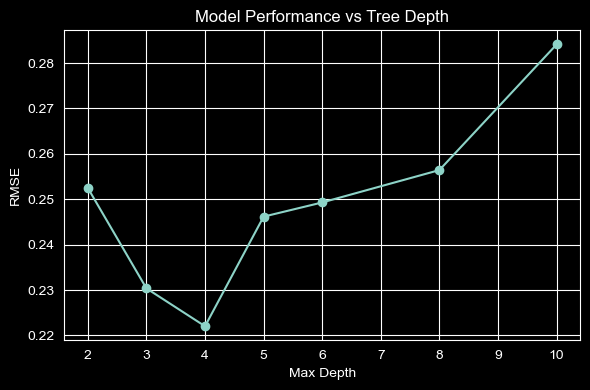

Saved figure to ../results/rmse_vs_depth.png


In [31]:
# Plot rmse_vs_depth
depths = [2, 3, 4, 5, 6, 8, 10]
rmse_list = []
r2_list = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_list.append(rmse)
    r2_list.append(r2)

plt.figure(figsize=(6, 4))
plt.plot(depths, rmse_list, marker="o")
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.title("Model Performance vs Tree Depth")
plt.grid(True)
plt.tight_layout()

plt.savefig("../results/rmse_vs_depth.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to ../results/rmse_vs_depth.png")

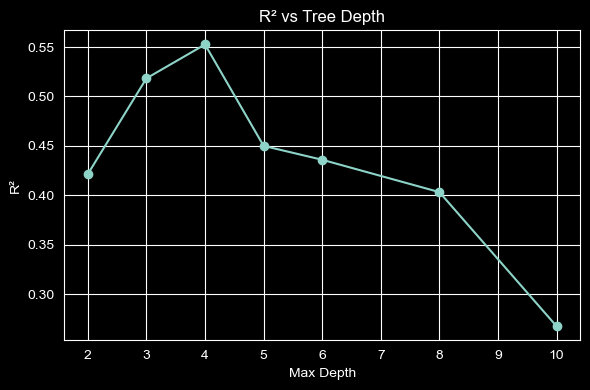

Saved figure to ../results/r2_vs_depth.png


In [30]:
# Plot r2_vs_depth
plt.figure(figsize=(6, 4))
plt.plot(depths, r2_list, marker="o")
plt.xlabel("Max Depth")
plt.ylabel("R²")
plt.title("R² vs Tree Depth")
plt.grid(True)
plt.tight_layout()

plt.savefig("../results/r2_vs_depth.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to ../results/r2_vs_depth.png")

In [32]:
# Save model parameters
model_params_df = pd.DataFrame([
    {
        "model": "DecisionTreeRegressor",
        "max_depth": 4,
        "random_state": 42,
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    }
])

model_params_df.to_csv("../results/model_summary.csv", index=False)
print(f"Saved model summary to ../results/model_summary.csv")

Saved model summary to ../results/model_summary.csv


In [33]:
# Save feature importance
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance_df = feature_importance.reset_index()
feature_importance_df.columns = ["feature", "importance"]

feature_importance_df.to_csv("../results/feature_importance.csv", index=False)
print("Saved feature importance to ../results/feature_importance.csv")

Saved feature importance to ../results/feature_importance.csv
